<h1 align="center">~Drugi domaći zadatak~</h1> 
<h2 align="center">Digitalna obrada slike (13E044DOS)</h2> 
<h3 align="left">Student: Magdalena Savić</h3> 
<h3 align="left">Broj indeksa: 2022/0351</h3> 

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import skimage as ski
from skimage import io, color, util, filters
import matplotlib.pyplot as plt
import scipy.ndimage as ndi    
import scipy.io
import scipy.signal as signal

data_dir = "../sekvence/"

#### Prvi dio

Na početku se traži da izvedemo izraz za diskretnu Furijeovu transformaciju dvodimenzionalne Gausove funkcije koja ima različite standardne devijacije po redovima i kolonama. 

Možemo krenuti od dvodimenzionalne Gausove funkcije u prostornom domenu:

$$f(x, y) = e^{-\left(\frac{x^2}{2\sigma_x^2} + \frac{y^2}{2\sigma_y^2}\right)}$$

Ovu funkciju zatim možemo zapisati i u diskretnom obliku:

$$f(n_1, n_2) = e^{-\left(\frac{n_1^2}{2\sigma_{n1}^2} + \frac{n_2^2}{2\sigma_{n2}^2}\right)}$$

gdje je $n_1 = 0, 1, ... , N_H - 1$, a $n_2 = 0, 1, ... , N_W - 1$.

Sada treba da izračunamo diskretnu Furijeovu transformaciju na sljedeći način:

$$F(u,v) = \sum_{n_1=0}^{N_H-1} \sum_{n_2=0}^{N_W-1} f(n_1,n_2)\, e^{-j 2\pi \left(\frac{un_1}{N_H} + \frac{vn_2}{N_W}\right)}$$

Dalji postupak je sljedeći:

$$F(u,v) =[\sum_{n_1=0}^{N_H-1} e^{-\frac{n_1^2}{2\left(\sigma_r^{S}\right)^2}}\;e^{-j 2\pi \frac{u n_1}{N_H}}][\sum_{n_2=0}^{N_W-1} e^{-\frac{n_2^2}{2\left(\sigma_c^{S}\right)^2}}\;e^{-j 2\pi \frac{v n_2}{N_W}}]$$

Odavde vidimo da je dovoljno samo da izračunamo DFT jednodimenzionalne Gausove funkcije kako bismo dobili DFT dvodimenzionalne Gausove funkcije. Pošto je ovo analitički izuzetno komplikovano da se izračuna, isti rezultat možemo dobiti ako izračunamo Furijeovu transformaciju kontinualne Gausove funkcije i zatim je diskretizujemo.

Zbog linearnosti, funkcija koju ćemo analizirati je oblika $g(x) = e^{-\frac{x^2}{2\sigma_S^2}}$.

Furijeova transformacija ove funkcije se računa na sljedeći način:

$$G(\mu) = \int_{-\infty}^{\infty} g(x) \, e^{-j 2 \pi \mu x} \, dx = \int_{-\infty}^{\infty} e^{-\frac{x^2}{2\sigma_S^2}} \, e^{-j 2 \pi \mu x} \, dx = \int_{-\infty}^{\infty} e^{\frac{x^2}{2\sigma_S^2} + j 2 \pi \mu x} \, dx$$

$$G(\mu) = \sigma_S \, \sqrt{2\pi} \, e^{-2 \pi^2 \sigma_S^2 \mu^2}$$

Dobijenu transformaciju možemo da diskretizujemo tako što ćemo umjesto $\mu$ napisati $\frac{u}{N}$ i nakon ovoga dobijamo funkciju koja je oblika:

$$G(u) \propto e^{-\frac{2\pi^2\sigma_S^2u^2}{N^2}}$$

Izraz $\sigma_S \, \sqrt{2\pi} $ predstavlja amplitudu $A$, a pošto je (diskretna) Furijeova transformacija linearna, to znači da važi $\mathcal{F}\{A x(t)\}=A X(\omega)$.
Uzimajući ovo u obzir, traženi izraz za diskretnu Furijeovu transformaciju dvodimenzionalne Gausove funkcije je:

$$\boxed{F(u,v) = 2\pi\sigma_r^{S}\sigma_c^{S} e^{-2\pi^2\left(\frac{u(\sigma_r^{S})^2}{N_H^2} + \frac{v(\sigma_c^{S})^2}{N_W^2}\right)}}$$

Ovim postupkom jasno vidimo da je Gausova funkcija u frekvencijskom domenu takođe Gausova.

Pošto su Gausove funkcije oblika $g(x)$ vrlo lako možemo da odredimo izraze za $\sigma_r^{F}$ i $\sigma_c^{F}$.

$$\frac{u^2}{2(\sigma^{F})^2} = \frac{2\pi^2(\sigma^{S})2u^2}{N^2}$$
$$\Downarrow$$
$$\boxed{\sigma_r^{F} = \frac{N_H}{2\pi\sigma_r^{S}}} \quad \text{ i } \quad \boxed{\sigma_c^{F} = \frac{N_W}{2\pi\sigma_c^{S}}}$$

In [31]:
def lpfilter(Ny, Nx, sigma):
    # ovo je korisceno na vjezbama, dobri su rezultati, ali mogu biti i bolji kao sto se vidi dole
    '''if (Ny%2 == 0):
        y = np.arange(0,Ny) - Ny/2 + 0.5
    else:
        y = np.arange(0,Ny) - (Ny-1)/2
    
    if (Nx%2 == 0):
        x = np.arange(0,Nx) - Nx/2 + 0.5
    else:
        x = np.arange(0,Nx) - (Nx-1)/2'''

    # sa ovim su bolji rezultati tj. greske su dosta manje
    # kreiranje koordinatnog sistema sa nulom u centru slike
    center_y = Ny // 2    
    center_x = Nx // 2

    y = np.arange(0, Ny) - center_y
    x = np.arange(0, Nx) - center_x

    # kreiranje mreze koordinata
    X, Y = np.meshgrid(x, y)

    # izracunavanje rastojanja od centra za svaku tacku
    D = np.sqrt(np.square(X) + np.square(Y))

    # formula za Gausovu f-ju
    filter_mask = np.exp(-np.square(D)/(2*np.square(sigma)))
    
    return filter_mask

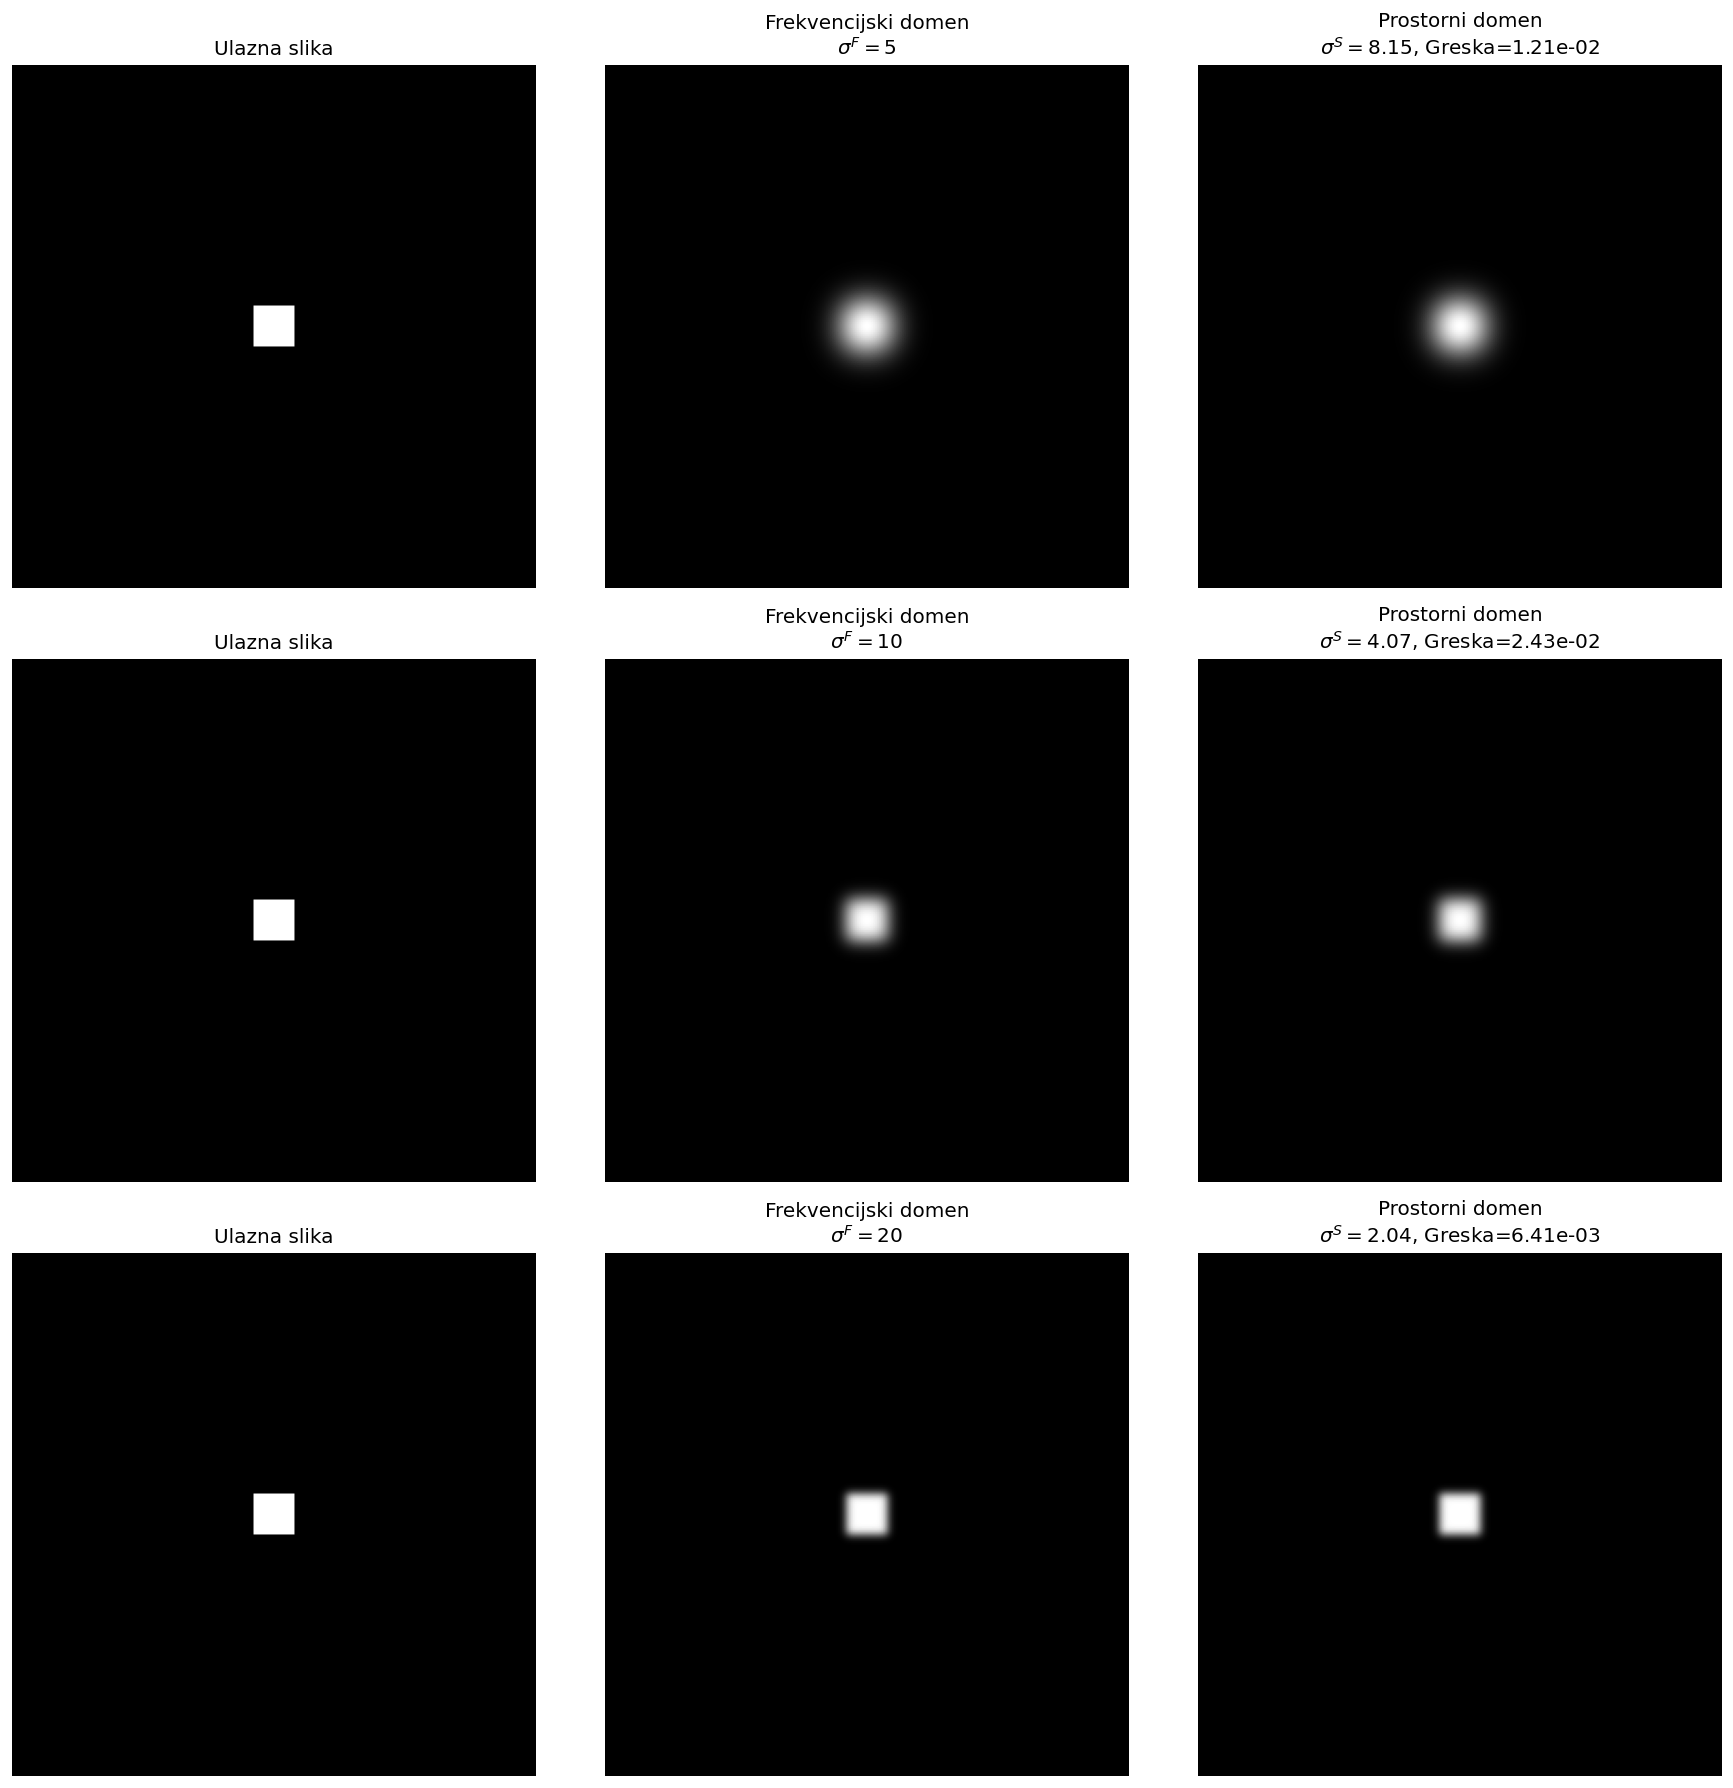

In [32]:
img = util.img_as_float(io.imread(data_dir + "square_256x256.tif"))
sigmas = [5, 10, 20]    # vrijednosti u frekvencijskom domenu

def calculate_and_plot(img, sigmas):
    [Ny, Nx] = np.shape(img)

    # prelazak u frekvencijski domen - samo radimo fft
    img_fft = np.fft.fftshift(np.fft.fft2(img))

    fig, axes = plt.subplots(nrows=len(sigmas), ncols=3, figsize=(15, 5*len(sigmas)), dpi=120)
    if len(sigmas) == 1: axes = np.array([axes])

    for i, s_F in enumerate(sigmas):
        filt_freq = lpfilter(Ny, Nx, sigma=s_F)    # generisanje filtra
        
        img_fft_filt = img_fft * filt_freq    # filtriranje
        # vracanje u prostorni domen: radi se klasican ifft, pa siftujemo nazad i uzimamo realni dio jer zbog numerickih gresaka mogu postojati imaginarni ostaci
        img_filt_freq = np.real(np.fft.ifft2(np.fft.ifftshift(img_fft_filt)))
        img_filt_freq = np.clip(img_filt_freq, 0, 255) # slika se ne ucitava kao float pa mora ovako

        # koristimo izvedenu formulu za racunanje sigme za prostorni domen
        s_S = Ny / (2 * np.pi * s_F)

        # filtriramo i u prostornom domenu radi poredjenja
        img_filt_spatial = filters.gaussian(img, sigma=s_S, mode='wrap')

        # racunanje maksimalne apsolutno greske
        diff = np.max(np.abs(img_filt_freq - img_filt_spatial))

        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_axis_off()
        axes[i, 0].set_title('Ulazna slika')

        axes[i, 1].imshow(img_filt_freq, cmap='gray')
        axes[i, 1].set_axis_off()
        axes[i, 1].set_title(f'Frekvencijski domen\n$\sigma^F = {s_F}$')

        axes[i, 2].imshow(img_filt_spatial, cmap='gray')
        axes[i, 2].set_axis_off()
        axes[i, 2].set_title(f'Prostorni domen\n$\sigma^S = {s_S:.2f}$, Greska={diff:.2e}')
        #print(np.max(img_filt_freq))

    plt.tight_layout()

calculate_and_plot(img, sigmas)

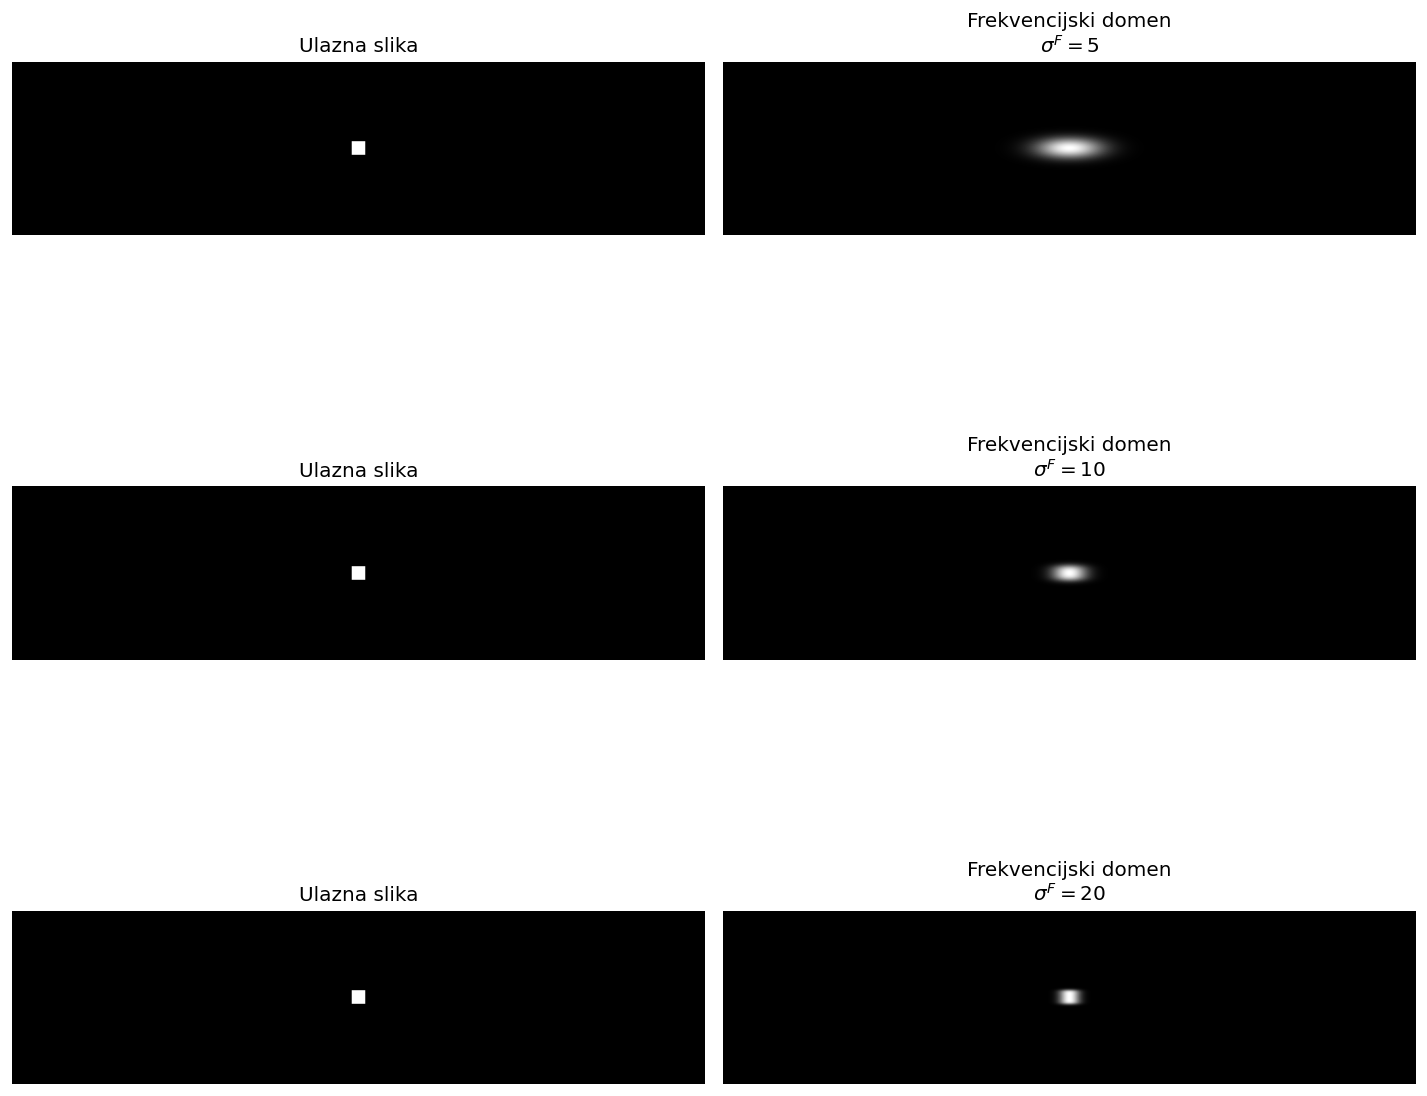

In [33]:
# kod je skoro pa identican kao u prethodnom slucaju

img_rect = util.img_as_float(io.imread(data_dir + "square_256x1024.tif"))

def calculate_and_plot(img, sigmas):
    [Ny, Nx] = np.shape(img)
    
    img_fft = np.fft.fftshift(np.fft.fft2(img))
    
    fig, axes = plt.subplots(nrows=len(sigmas), ncols=2, figsize=(12, 4*len(sigmas)), dpi=120)
    if len(sigmas) == 1: axes = np.array([axes])

    for i, s_F in enumerate(sigmas):
        filt_freq = lpfilter(Ny, Nx, sigma=s_F)
        
        img_fft_filt = img_fft * filt_freq
        img_filt_freq = np.real(np.fft.ifft2(np.fft.ifftshift(img_fft_filt)))
        
        img_filt_freq = np.clip(img_filt_freq, 0, 1)  # ovde se dobro ucita
        
        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_axis_off()
        axes[i, 0].set_title(f'Ulazna slika')
        
        axes[i, 1].imshow(img_filt_freq, cmap='gray')
        axes[i, 1].set_axis_off()
        axes[i, 1].set_title(f'Frekvencijski domen\n$\sigma^F = {s_F}$')

    plt.tight_layout()

calculate_and_plot(img_rect, sigmas)

In [34]:
# f-ja za Gausov filtar koji ima razlicite sigme po osama
def lpfilter_anisotrop(Ny, Nx, sigma_r, sigma_c):
    center_y = Ny // 2
    center_x = Nx // 2
    
    y = np.arange(0, Ny) - center_y
    x = np.arange(0, Nx) - center_x
    
    X, Y = np.meshgrid(x, y)

    # klasicna formula za Gausovu funkciju
    exponent = - (np.square(X) / (2 * np.square(sigma_c))) - (np.square(Y) / (2 * np.square(sigma_r)))
    filter_mask = np.exp(exponent)
    
    return filter_mask

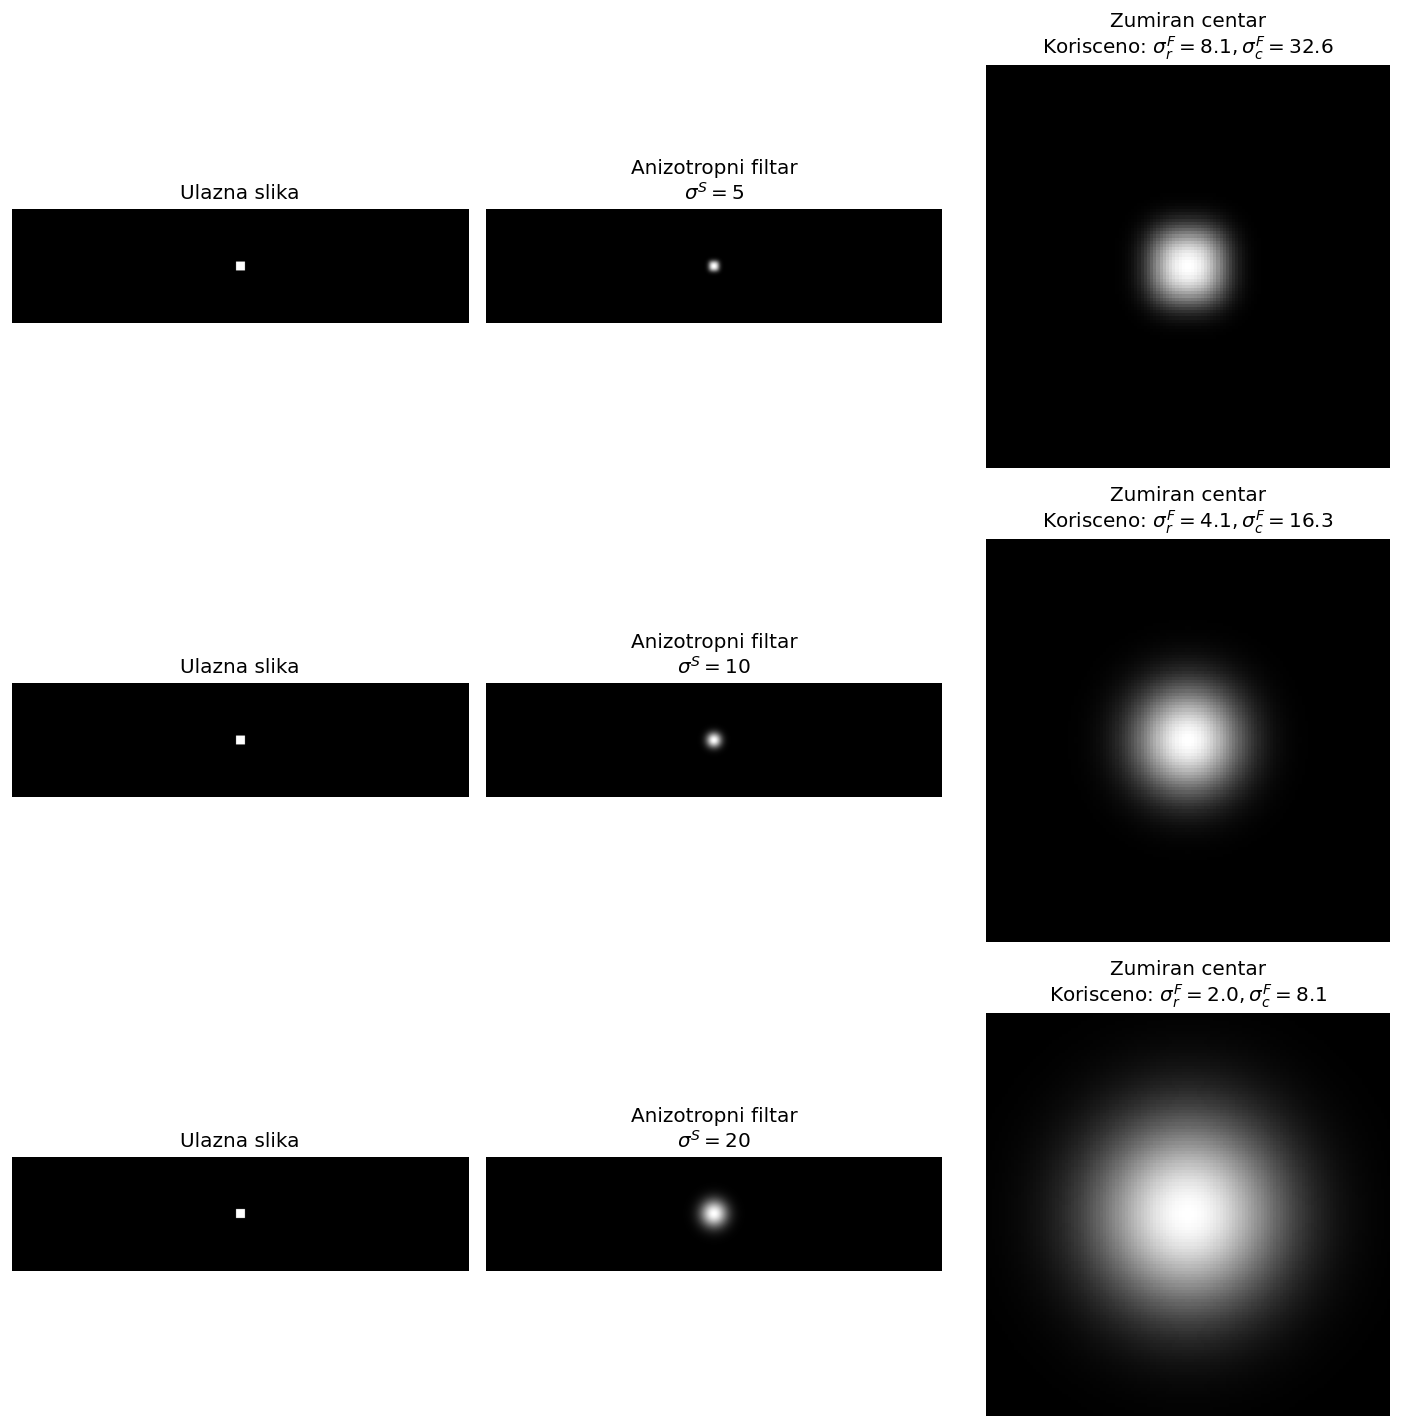

In [35]:
# 90% koda je isto kao i u prethodnim primjerima
def calculate_and_plot(img, sigmas):
    [Ny, Nx] = np.shape(img)
    
    img_fft = np.fft.fftshift(np.fft.fft2(img))
    
    fig, axes = plt.subplots(nrows=len(sigmas), ncols=3, figsize=(12, 4*len(sigmas)), dpi=120)
    if len(sigmas) == 1: axes = np.array([axes])

    for i, s_S in enumerate(sigmas):
        # racunamo na osnovu izvedenih formula sa pocetka zadatka
        sig_F_r = Ny / (2 * np.pi * s_S)  
        sig_F_c = Nx / (2 * np.pi * s_S)  
        
        filt_freq = lpfilter_anisotrop(Ny, Nx, sigma_r=sig_F_r, sigma_c=sig_F_c)
        
        img_filt = np.real(np.fft.ifft2(np.fft.ifftshift(img_fft * filt_freq)))
        img_filt = np.clip(img_filt, 0, 1) 

        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_axis_off()
        axes[i, 0].set_title(f'Ulazna slika')
        
        axes[i, 1].imshow(img_filt, cmap='gray')
        axes[i, 1].set_axis_off()
        axes[i, 1].set_title(f'Anizotropni filtar\n$\sigma^S={s_S}$')
        
        cy, cx = Ny//2, Nx//2
        zoom_region = img_filt[cy-64:cy+64, cx-64:cx+64]
        
        axes[i, 2].imshow(zoom_region, cmap='gray')
        axes[i, 2].set_axis_off()
        axes[i, 2].set_title(f'Zumiran centar\nKorisceno: $\sigma^F_r={sig_F_r:.1f}, \sigma^F_c={sig_F_c:.1f}$')

    plt.tight_layout()

calculate_and_plot(img_rect, sigmas)

In [36]:
import time

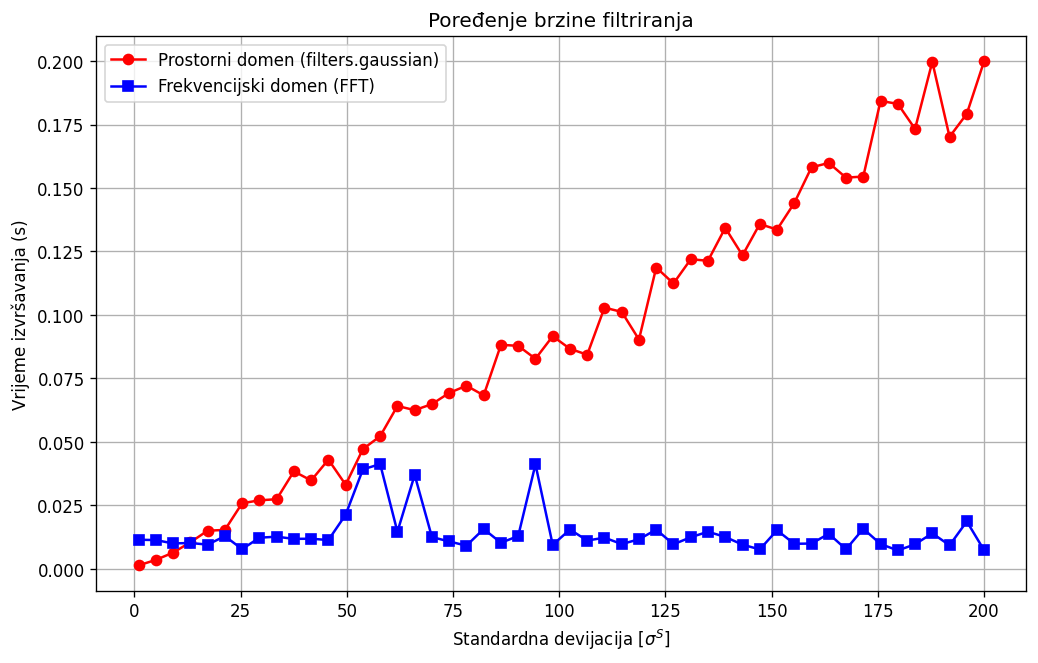

In [37]:
def filtering_time(img):
    Ny, Nx = np.shape(img)

    # testiramo za veliki opseg "sigmi" iz prostornog domena
    sigmas_S = np.linspace(1, 200, 50)
    
    times_spatial = []
    times_freq = []
    
    N_runs = 10    # broj ponavljanja
    
    for s_S in sigmas_S:
        # mjerenje vremena filtriranja u prostornom domenu
        start = time.time()
        for _ in range(N_runs):
            _ = filters.gaussian(img, sigma=s_S, mode='wrap')
        avg_time = (time.time() - start) / N_runs
        times_spatial.append(avg_time)

        # mjerenje vremena filtriranja u frekvencijskom domenu
        s_F_r = Ny / (2 * np.pi * s_S) 
        s_F_c = Nx / (2 * np.pi * s_S)
        
        start = time.time()
        for _ in range(N_runs):
            F = np.fft.fft2(img)
            F = np.fft.fftshift(F)
            filt_freq = lpfilter_anisotrop(Ny, Nx, s_F_r, s_F_c) 
            res = np.fft.ifft2(np.fft.ifftshift(F * filt_freq))
        avg_time = (time.time() - start) / N_runs
        times_freq.append(avg_time)

    plt.figure(figsize=(10, 6), dpi=120)
    plt.plot(sigmas_S, times_spatial, 'r-o', label='Prostorni domen (filters.gaussian)')
    plt.plot(sigmas_S, times_freq, 'b-s', label='Frekvencijski domen (FFT)')
    plt.xlabel('Standardna devijacija $[\sigma^S]$')
    plt.ylabel('Vrijeme izvršavanja (s)')
    plt.title('Poređenje brzine filtriranja')
    plt.legend()
    plt.grid(True)

filtering_time(img)

Gausov filtar je jedinstven po tome što je njegova Furijeova transformacija takođe Gausova funkcija. Ova osobina nam omogućava da efekat zamućenja, koji se u prostornom domenu postiže konvolucijom slike sa Gausovim jezgrom, ekvivalentno postignemo u frekvencijskom domenu množenjem spektra slike sa odgovarajućom Gausovom funkcijom.

Ključni izazov je bio odrediti vezu između širine Gausove funkcije u prostornom domenu ($\sigma^{S}$) i njene širine i frekvencijsom domenu ($\sigma^{F}$), što je i urađeno na samom početku ovog zadatka.

Prvi dio testiranja je urađen nad slikom dimenzija $256\times256$ uz pomoćog izotropnog `lpfilter()` sa časova vježbi, sa parametrima $\sigma^{F} \in \{5, 10, 20\}$. Na osnovu izvedene formule, izračunate su ekvivalentne prostorne devijacije $\sigma^{S}$. Poređenjem slike filtrirane u frekvencijskom domenu i slike filtrirane u prostornom domenu, dobijena je maksimalna apsolutna greška reda veličine od $10^{-2}$ do $10^{-3}$. Greška je nastala zato što funkcija `filters.gaussian()` radi odsjecanje Gausovog jezgra na određenoj udaljenosti od centra, dok se u frekvencijskom domenu podrazumijeva da funkcija djeluje na cijeloj periodi signala bez bilo kakvih odsijecanja. Takođe, izvedena veza između $\sigma^{S}$ i $\sigma^{F}$ je egzaktna za kontinualne signale. Prilikom diskretizacije, može doći do manjih odstupanja usljed odabiranja funkcije što se manifestuje kao greška aproksimacije.  Uprkos ovim numeričkim razlikama, vizuelni efekat zamućenja je identičan, a greška je dovoljno mala da se u praktičnim primjenama ova dva pristupa mogu smatrati ekvivalentnim.

U drugom dijelu posmatrana je slika sa odnosom stranica $1:4$. Pošto smo primijenili isti filtar kao u prethodnom slučaju, rezultat filtriranja u prostoru je pokazao anizotropno ponašanje. Slika je mnogo više blurovana u horizontalnom pravcu i liči na neku elipsu. Zašto se ovo desilo? Zato što, primjenom izvedenih formula, mi dobijamo da je $\sigma_{x}^{S} = 4 \cdot \sigma_{y}^{S}$ tj. dobijamo da je zamućenje po horizontalnoj osi 4 puta veće nego zamućenje po vertikalnoj osi. Da bismo imali ravnomjerno zamućenje, filtar mora biti prilagođen dimenzijama slike, što je na kraju krajeva, i urađeno u sljedećem primjeru implementacijom funkcije `lpfilter_anisotrop()`, a rezultati poslije ovakvog filtriranja pokazuju da je filtar pravilno implementiran jer se dobijaju jednaka zamućenja sa svih strana pravougaonika.

Krajnji dio zadatka poredi vrijeme izvršavanja filtriranja u zavisnosti od stepena zamućenja ($\sigma^{S}$).
- Frekvencijski domen (FFT): Plava linija na grafiku je praktično ravna (konstantna). Razlog je taj što složenost FFT algoritma zavisi samo od broja piksela slike $O(NlogN)$ i ne zavisi od sadržaja filtra. Bilo da je $\sigma$ malo i veliko, operacije su iste (FFT -> matrično množenje -> IFFT).

- Prostorni domen: Crvena linija pokazuje linearni rast vremena sa povećanjem $\sigma^{S}$. Razlog za to je što se implementacija Gausovog filtra u prostoru obično vrši konvolucijom sa maskom čija veličina zavisi od $\sigma$. Što je veće $\sigma$, maska je veća, i potrebno je više operacija množenja i sabiranja za svaki piksel. 

#### Drugi dio

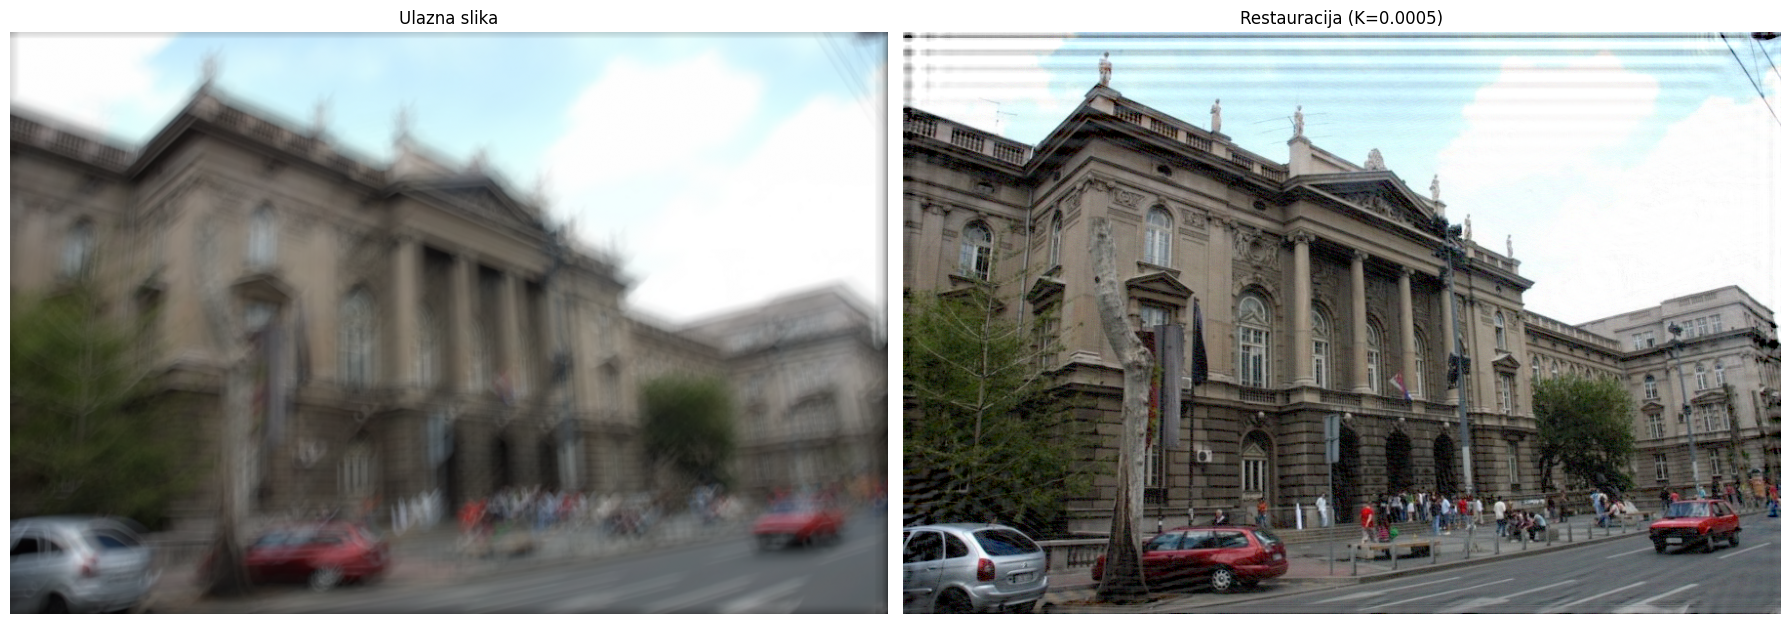

In [3]:
# pomocne f-je:
# uklanjanje i dodavanje gama korekcije, ucitavanje txt fajla
def srgb_to_linear(img):
    return np.power(img, 2.2)

def linear_to_srgb(img):
    return np.power(np.clip(img, 0, 1), 1/2.2)

def load_kernel_from_txt(filepath):
    kernel = np.loadtxt(filepath)
    return kernel

img_blur = util.img_as_float(io.imread(data_dir + "etf_blur.png"))    # ucitavanje slike
img_linear = srgb_to_linear(img_blur)    # prebacivanje u linearni domen

h_motion = load_kernel_from_txt(data_dir + "blur_kernel.txt")    # ucitavanje kernela
Kh, Kw = h_motion.shape    # dimenzije kernela

# dimenzije slike
pad_h = img_linear.shape[0]
pad_w = img_linear.shape[1]

# pad-ujemo sliku da bismo smanjili ripplove jer fft podrazumijeva da je slika periodicna i onda ako ovo ne uradimo mogu biti bas uzasni rezultati
img_padded = np.pad(img_linear, ((pad_h, pad_h), (pad_w, pad_w), (0, 0)), mode='edge')

[Py, Px, Pc] = img_padded.shape

# kernel mora biti istih dimenzija kao slika kako bi mogao da se pomnozi sa slikom u frekvencijskom domenu
h_pad_spatial = np.zeros((Py, Px))
h_pad_spatial[0:Kh, 0:Kw] = h_motion   # stavljamo kernel u gornji lijevi ugao velike nula matrice
# centriranje kernela - u suprotnom su opet rezultati uzas
h_pad_spatial = np.roll(h_pad_spatial, -Kh//2, axis=0)
h_pad_spatial = np.roll(h_pad_spatial, -Kw//2, axis=1)

# radimo fft kernela
H_freq = np.fft.fftshift(np.fft.fft2(h_pad_spatial))
H_freq = np.where(H_freq == 0, 1e-10, H_freq)

img_restored_padded = np.zeros_like(img_padded)

# implementacije Wienerovog filtra
k = 0.0005
W = (np.abs(H_freq)**2) / (np.abs(H_freq)**2 + k)

# restauracija slike po svakom kanalu boje
for c in range(Pc):
    # standardni fft
    img_fft = np.fft.fftshift(np.fft.fft2(img_padded[:, :, c]))
    # radimo filtriranje
    img_fft_est = (img_fft/H_freq) * W
    # standardni ifft
    img_restored_padded[:, :, c] = np.real(np.fft.ifft2(np.fft.ifftshift(img_fft_est)))

# vracamo sliku na originalne dimenzije
img_restored_linear = img_restored_padded[pad_h:-pad_h, pad_w:-pad_w, :]

# primjenjujemo gama korekciju
img_final = linear_to_srgb(img_restored_linear)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 10), dpi=100)
ax = axes.ravel()
ax[0].imshow(img_blur)
ax[0].set_title('Ulazna slika')
ax[0].axis('off')
ax[1].imshow(img_final)
ax[1].set_title(f'Restauracija (K={k})')
ax[1].axis('off')
plt.tight_layout()

U ovom zadatku se od nas traži da restauiramo digitalnu sliku koja je degradirana usljed pomijeranja kamere ("motion blur"). Kernel zamućenja je poznat, ali slika nije u "sirovom" (RAW) linearnom formatu, već je gama korigovana (sRGB). Cilj je bio primijeniti odgovarajuće pred-procesiranje i Wiener-ov filtar u frekvencijskom domenu kako bi se povratila oštrina slike uz minimizaciju artefakata.

Da bi dekonvolucija bila uspješna, neophodno je prvo konvertovati sliku iz nelinearnog sRGB prostora u linearni prostor. Sve operacije filtriranja vrše se u ovom domenu, a rezultat se na kraju vraća u sRGB. Proces degradacije modelujemo kao:
$$G(u, v) = H(u, v) \cdot F(u, v) + N(u, v)$$
gde je $G$ spektar zamućene slike, $H$ spektar kernela zamućenja, $F$ spektar idealne slike, i $N$ spektar šuma.

Kao rješenje koristi se Wiener-ov filtar koji minimizuje srednju kvadratnu grešku između originalne i restaurirane slike. Parametar $K$ predstavlja inverznu vrijednost odnosa signal-šum (SNR). U ovom slučaju $K$ je određen eksperimentalno i po mom mišljenju najbolji rezultati se dobijaju za $K = 0.0005$ (za veće $K$ slika postaje mutnija (ovdje Wiener-ov filtar efektivno radi kao $NF$ filtar), a za manje $K$ slika izgleda dobro ali se zato šum sve više i više povećava).

Pošto se filtriranje vrši u frekvencijskom domenu (množenjem), to odgovara konvoluciji u prostornom domenu. To izaziva prelivanje piksela sa jedne ivice slike na drugu. Da bi se ovo spriječilo, slika je prije transformacije proširena tehnikom kopiranja ivica (`mode='edge'`), čime se artefakti pomjeraju van regiona od interesa. Proširena slika ima mnogo veće dimenzije nego što bi to imalo smisla, ali nekon nekoliko sati pokušaja sa moje strane da se svi ripplovi uklone, čini mi se da ripplovi nisu toliko crni kao u nekim prethodnim slučajevima. (Što se tiče paddovanja tj. proširivanja, probala sam sve moguće opcije: i da proširim crnim pikselima i da koristim `mode='reflect'` i `mode='symmetric'` i probala sam paddovanje koje smo pominjali na predavanjima tj. mirroring - u suštini, na kraju, ništa nije bolje od ovoga što je već dobijeno.)

Kernel učitan iz fajla ima centar u geometrijskoj sredini matrice. Međutim, FFT algoritam podrazumijeva da je koordinatni početak $(0,0)$ u gornjem lijevom uglu. Ako se kernel ne translira (pomoću `np.roll`), restaurirana slika će biti prostorno pomjerena u odnosu na original.

Može se primijetiti, i da se pored svega ovoga, na slici nalaze neki šumovi/artefakti pored ivica i to je neizbježna posljedica dekonvolucije kada kernel ima oštre nule u spektru.

#### Treći dio

In [43]:
def estimate_noise_var(img, win=0, tol=0.001):
   
    def get_stats(image, w_size):
        # racunanje lokalne srednje vrijednosti tj mean
        # uniform_filter računa prosjek u kvadratnom prozoru w_size x w_size
        mean = ndi.uniform_filter(image, size=w_size, mode='reflect')
        # racunanje lokalne srednje kvadratne vrijednosti
        mean_sq = ndi.uniform_filter(image**2, size=w_size, mode='reflect')

        # racunanje lokalne varijanse
        local_var = mean_sq - mean**2

        # Beselova korekcija
        N = w_size * w_size
        if N > 1: local_var *= (N / (N - 1))

        # provjeravamo da nema negativnih vrijednosti
        local_var = np.maximum(local_var, 0)

        # odbacujemo ekstremne vrijednosti (ivice) koje imaju ogromnu varijansu
        v_min = 0
        v_max = np.percentile(local_var, 99)   # postavljamo kao gornju granicu histograma
        if v_max <= 0: v_max = 1e-9

        # kreiranje histograma lokalnih varijansi
        bins = np.linspace(v_min, v_max, 200)
        hist, bin_edges = np.histogram(local_var, bins=bins)

        # pronalazenje peak-a histograma
        max_idx = np.argmax(hist)
        peak_count = hist[max_idx]

        # vrijednost varijanse koja odgovara centru odgovarajuceg bina
        estimated_val = (bin_edges[max_idx] + bin_edges[max_idx+1]) / 2.0
        
        return estimated_val, peak_count
        
    # prvi slucaj kada je velicina prozora fiksna
    if win > 0:
        val, peak = get_stats(img, win)
        # sve ove vrijednosti se cuvaju zbog plotovanja kasnije
        estimate_noise_var.last_peak_count = peak 
        estimate_noise_var.last_window = win
        return val

    # automatski rezim tj iterativno se povecava prozor dok se procjena ne stabilizuje
    else:
        prev_est = None
        # krece se od 3x3 i povecava se za dva - neparni prozori su simetricni
        for w in range(3, 52, 2):
            curr_est, peak = get_stats(img, w)
            estimate_noise_var.last_peak_count = peak
            if prev_est is not None:
                # ako je promjena manja od tolerancije smatramo da smo nasli pravu vrijednost
                if abs(curr_est - prev_est) < tol:
                    estimate_noise_var.last_window = w
                    return curr_est
            prev_est = curr_est
        # ako petlja dodje do kraja vracamo poslednju vrijednost    
        estimate_noise_var.last_window = 51
        return prev_est

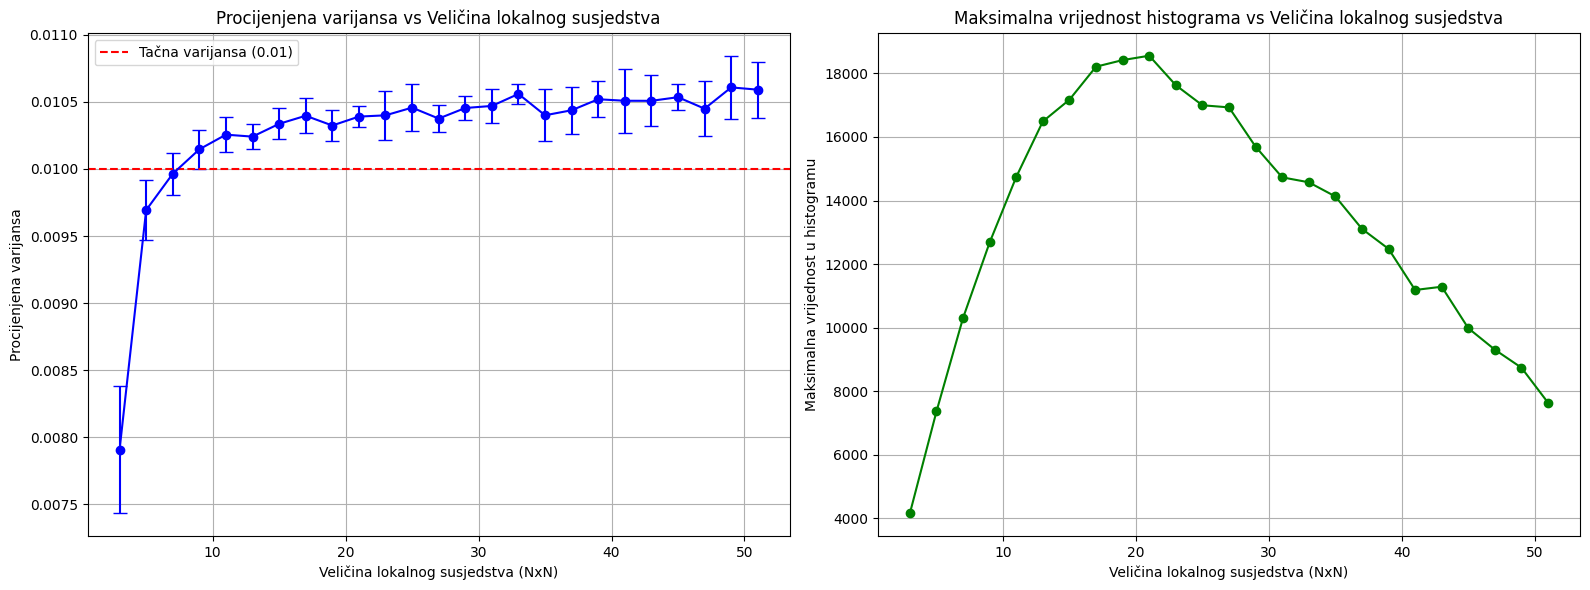

In [44]:
img_lena = util.img_as_float(io.imread(data_dir + "lena.tif"))

target_variance = 0.01
num_trials = 10 
window_sizes = range(3, 52, 2)

mean_estimates = []
std_estimates = []
hist_peaks = []

for w in window_sizes:
    trial_vars = []
    trial_peaks = []

    # monte carlo simulacija: dodajemo sum vise puta i usrednjavamo rezultate
    for _ in range(num_trials):
        noisy_img = util.random_noise(img_lena, mode='gaussian', var=target_variance)
        val = estimate_noise_var(noisy_img, win=w)
        peak = estimate_noise_var.last_peak_count
        trial_vars.append(val)
        trial_peaks.append(peak)
    
    mean_estimates.append(np.mean(trial_vars))
    std_estimates.append(np.std(trial_vars))
    hist_peaks.append(np.mean(trial_peaks))

# crtanje grafika...
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.errorbar(window_sizes, mean_estimates, yerr=std_estimates, fmt='-o', capsize=5, color='blue')
ax1.axhline(y=target_variance, color='r', linestyle='--', label=f'Tačna varijansa ({target_variance})')
ax1.set_title('Procijenjena varijansa vs Veličina lokalnog susjedstva')
ax1.set_xlabel('Veličina lokalnog susjedstva (NxN)')
ax1.set_ylabel('Procijenjena varijansa')
ax1.legend()
ax1.grid(True)

ax2.plot(window_sizes, hist_peaks, '-o', color='green')
ax2.set_title('Maksimalna vrijednost histograma vs Veličina lokalnog susjedstva')
ax2.set_xlabel('Veličina lokalnog susjedstva (NxN)')
ax2.set_ylabel('Maksimalna vrijednost u histogramu')
ax2.grid(True)

plt.tight_layout()

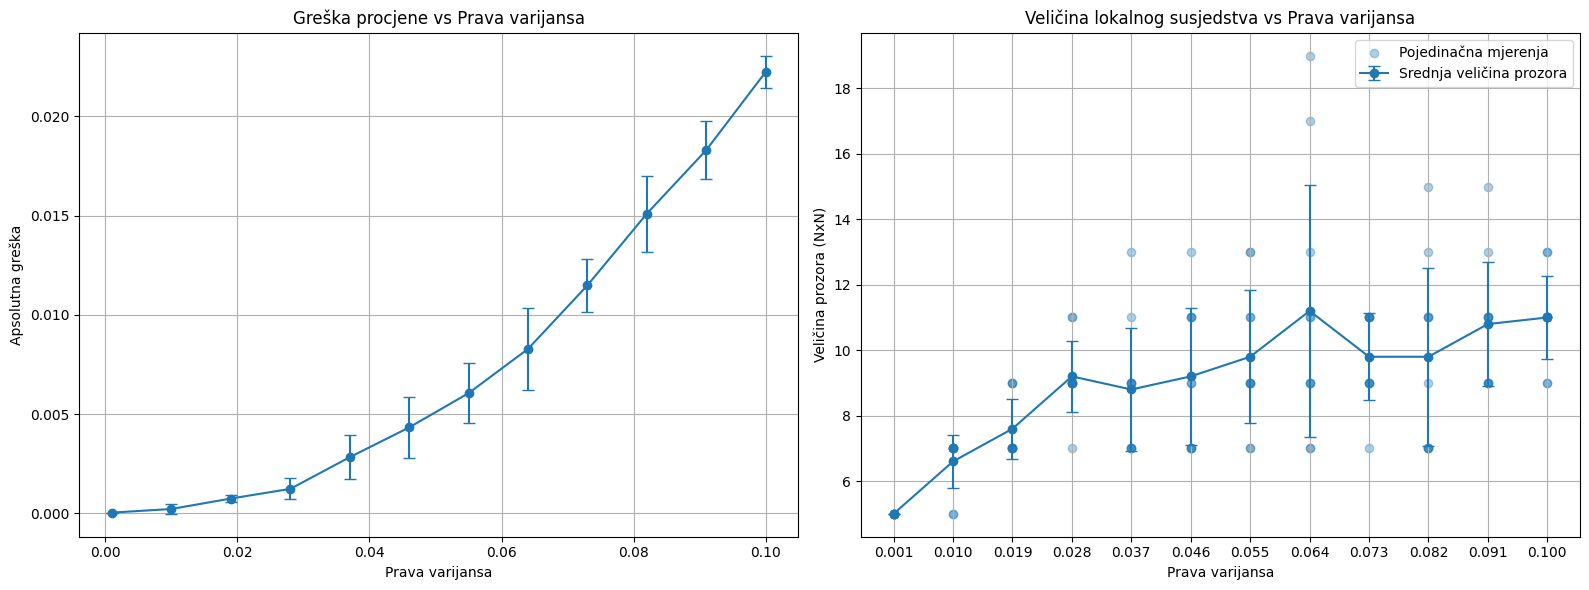

In [45]:
noise_levels = np.linspace(0.001, 0.1, 12)
num_trials = 10

mean_errors = []
std_errors = []
mean_windows = []
std_windows = []

all_windows = [] 

for var_target in noise_levels:
    trial_errors = []
    trial_windows = []

    for _ in range(num_trials):
        noisy_img = util.random_noise(img_lena, mode='gaussian', var=var_target)
        # pozivamo funkciju sa win=0 da bi ona sama odredila prozor
        est_val = estimate_noise_var(noisy_img, win=0, tol=0.001)
        chosen_w = getattr(estimate_noise_var, 'last_window', None)

        trial_errors.append(abs(est_val - var_target))
        trial_windows.append(chosen_w)

    mean_errors.append(np.mean(trial_errors))
    std_errors.append(np.std(trial_errors))
    mean_windows.append(np.mean(trial_windows))
    std_windows.append(np.std(trial_windows))

    all_windows.append(np.array(trial_windows))

x_scatter = np.repeat(noise_levels, num_trials)
y_scatter = np.concatenate(all_windows)

# crtanje grafika...
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.errorbar(noise_levels, mean_errors, yerr=std_errors, fmt='-o', capsize=4)
ax1.set_title('Greška procjene vs Prava varijansa')
ax1.set_xlabel('Prava varijansa')
ax1.set_ylabel('Apsolutna greška')
ax1.grid(True)

ax2.scatter(x_scatter, y_scatter, alpha=0.35, marker='o', label='Pojedinačna mjerenja')
ax2.errorbar(noise_levels, mean_windows, yerr=std_windows, fmt='-o', capsize=4, label='Srednja veličina prozora')
ax2.set_title('Veličina lokalnog susjedstva vs Prava varijansa')
ax2.set_xlabel('Prava varijansa')
ax2.set_ylabel('Veličina prozora (NxN)')
ax2.set_xticks(noise_levels)
ax2.grid(True)
ax2.legend()

plt.tight_layout()

Cilj ovog zadatka je implementacija i analiza algoritma za "blind" estimaciju varijanse šuma u slici, što znači da algoritam nema pristup originalnoj slici bez šuma. Metod se zasniva na statističkoj osobini prirodnih slika da sadrže značajne dijelove uniformnih površina. Ideja je sljedeća:
- Varijansa idealnu uniformne površine je $0$.
- Ako slici dodamo aditivni šum varijanse $\sigma_{n}^2$, varijansa uniformnih regiona postaje približno jednaka $\sigma_{n}^2$.
- Varijansa regiona sa ivicama i teksturama je mnogo veća od $\sigma_{n}^2$.

Algoritam računa lokalnu varijansu za svaki piksel u okolini $N \times N$. Ako napravimo histogram ovih lokalnih varijansi, očekujemo izražen peak na mjestu koje odgovara varijansi šuma, jer najveći broj blokova u slici pripada upravo tim uniformnim dijelovima.

Funkcija je prvo pokrenuta za fiksnu varijansu šuma ($0.01$) uz promjenu veličine prozora.

Procijenjena varijansa vs Veličina lokalnog susjedstva:
- Mali prozori ($3 \times 3$ - $5 \times 5$): Vidimo da algoritam značajno potcjenjuje varijansu (tačke su ispod crvene linije). Ovo je posljedica statističke nepouzdanosti malog uzorka. Iako koristimo Beselovu korekciju, mali broj piksela (9 ili 25) nije dovoljan da formira stabilan histogram, pa je detekcija peak-a otežana i neprecizna.
- Srednji prozori ($7 \times 7$ - $21 \times 21$): Procjena konvergira ka tačnoj vrijednosti (0.01) i postaje stabilna. Ovo je optimalni opseg za ovaj nivo šuma.
- Veliki prozori: Procjena ostaje blizu tačne vrijednosti, ali standardna devijacija (vertikalne linije greške) blago raste.

Maksimalna vrijednost histograma vs Veličina lokalnog susjedstva:
- Kako povećavamo prozor, statistika unutar uniformnih blokova postaje sve preciznija. Varijansa "estimatora varijanse" opada, što znači da se vrijednosti u histogramu sve više grupišu oko prave vrijednosti. Zato peak postaje viši i uži.
- Nakon određene tačke, pik počinje da opada. Razlog je geometrijske prirode: što je prozor veći, to je manja vjerovatnoća da ćemo naći "savršeno uniforman" blok te veličine koji ne zahvata neku ivicu ili detalj. Broj "čistih" uniformnih blokova opada, pa samim tim i visina peak-a u histogramu.
- Zakljućak je da je najbolja veličina prozora tamo gdje je peak najviši ($20 \times 20$), jer tu imamo najbolji balans između statističke preciznosti i očuvanja lokalnosti.

Poslije ovoga, funkcija je pokrenuta i u automatskom režimu. Algoritam sam bira veličinu prozora iterativno povećavajući $N$ sve dok se procjena ne stabilizuje.

Greška procjene vs Prava varijansa:
- Greška raste sa povećanjem količine šuma. Ovo je očekivano jer jači šum više maskira sliku i teže je razdvojiti "uniformni dio sa šumom" od "blage teksture".
- Ipak, greška je i za najveći šum (0.1) relativno mala, što pokazuje robusnost metode.

Veličina lokalnog susjedstva vs Prava varijansa:
- Vidimo jasan trend – što je veći šum, algoritam automatski bira veći prozor.
- Kada je šum mali (npr. 0.001), uniformne površine su veoma glatke i statistika se brzo stabilizuje čak i na malim prozorima (oko $5 \times 5$). Međutim, kada je šum veliki (0.1), varijabilnost unutar malog prozora je ogromna. Algoritam mora da poveća prozor (sve do $12 \times 12$ ili $15 \times 15$ kako bi sakupio dovoljno piksela da statistički "ispegla" uticaj šuma i dobije stabilnu procjenu varijanse koja se ne mijenja drastično sa daljim povećanjem prozora.
- Plave tačke (pojedinačna mjerenja) pokazuju da postoji varijansa u izboru prozora, ali srednja vrijednost (linija) jasno prati logiku: više šuma znači veći prozor za usrednjavanje.

U suštini, implementirani algoritam uspješno procjenjuje varijansu šuma koristeći pretpostavku o uniformnim površinama. Pokazano je da izbor veličine prozora predstavlja kompromis između statističke preciznosti (zahtjeva veći prozor) i stacionarnosti slike (zahtjeva manji prozor). Automatski režim rada efikasno rješava ovaj problem adaptacijom veličine prozora u zavisnosti od nivoa šuma, postižući zadovoljavajuću tačnost u širokom opsegu varijansi.

#### Četvrti dio

U ovom zadatku se traži da se implementira standardni Self-Guided filtar, kao i njegova optimizovana verzija Fast Self-Guided filtar. Kao referenca za implementaciju korišćeni su naučni radovi dati u prilogu domaćeg zadatka.

U kodu, za implementaciju, korišćena je funkcija `ndi.convolve()` koja realizuje generalizovano 2D konvoluciju sa kernelom sačinjeni od jedinica normalizovanih brojem elemenata. Ova funkcija je upotrebljena kako bi se eksplicitno demonstrirala zavisnost algoritamske složenosti od veličine prozora $(R)$. Pored ove funkcije postoji i funkcija `ndi.uniform_filtar()` koja je znatno optimizovanija jer koristi separabilnost box filtra čime postiže konstantnu složenost $O(1)$ po pikselu, za razliku od već pomenute `ndi.convolve()` koja vrši punu 2D konvoluciju. To znači da za svaki piksel mora da izvrši $(2R + 1)^2$ operacija množenja i sabiranja.

In [47]:
def dos_self_guided_filter(img, R, epsilon):
    # rekurzivni poziv za slike u boji
    if img.ndim == 3:
        rows, cols, channels = img.shape
        out = np.zeros_like(img)
        for c in range(channels):
            out[:, :, c] = dos_self_guided_filter(img[:, :, c], R, epsilon)
        return out

    # kreiranje box kernela
    window_size = 2 * R + 1
    # kreiramo matricu jedinica i dijelimo sa brojem elemenata da dobijemo prosjek
    kernel = np.ones((window_size, window_size)) / (window_size ** 2)  
    
    #mean = ndi.uniform_filter(img, size=window_size, mode='reflect')
    #mean_sq = ndi.uniform_filter(img * img, size=window_size, mode='reflect')

    mean = ndi.convolve(img, weights=kernel, mode='reflect')
    mean_sq = ndi.convolve(img * img, weights=kernel, mode='reflect')
    
    var = mean_sq - mean * mean    # racunanje varijanse

    # racunanje koeficijenata a i b
    a = var / (var + epsilon)
    b = mean - a * mean
    
    #mean_a = ndi.uniform_filter(a, size=window_size, mode='reflect')
    #mean_b = ndi.uniform_filter(b, size=window_size, mode='reflect')

    # usrednjavanje koeficijenata a i b
    mean_a = ndi.convolve(a, weights=kernel, mode='reflect')
    mean_b = ndi.convolve(b, weights=kernel, mode='reflect')

    # kranja rekonstrukcija slike
    q = mean_a * img + mean_b
    
    return q

In [48]:
# pomocna f-ja za racunanje fast self-guided filtra
def reduce_box(img, s):
    h, w = img.shape
    # h_new i w_new moraju biti djeljivi sa s
    h_new = (h // s) * s
    w_new = (w // s) * s
    img_cropped = img[:h_new, :w_new]
    return img_cropped.reshape(h_new // s, s, w_new // s, s).mean(axis=(1, 3))

In [49]:
def dos_fast_self_guided_filter(img, R, epsilon, s=4):
    # rekurzivni poziv za slike u boji
    if img.ndim == 3:
        rows, cols, channels = img.shape
        out = np.zeros_like(img)
        for c in range(channels):
            out[:, :, c] = dos_fast_self_guided_filter(img[:, :, c], R, epsilon, s)
        return out
    
    h, w = img.shape

    # ako je s = 1 ili manje ili ako je radijus manji, koristi se standardni self-guided filtar
    if s <= 1 or R < s:
        return dos_self_guided_filter(img, R, epsilon)

    # decimacija slike
    img_sub = reduce_box(img, s)
    h_sub, w_sub = img_sub.shape

    # racunanje radijusa za decimiranu sliku
    R_sub = max(1, int(np.round(R / s)))
    window_size_sub = 2 * R_sub + 1

    kernel_sub = np.ones((window_size_sub, window_size_sub)) / (window_size_sub ** 2)
    
    #mean = ndi.uniform_filter(img_sub, size=window_size_sub, mode='reflect')
    #mean_sq = ndi.uniform_filter(img_sub * img_sub, size=window_size_sub, mode='reflect')

    # ista logika kao i za standardni self-guided filtar
    mean = ndi.convolve(img_sub, weights=kernel_sub, mode='reflect')
    mean_sq = ndi.convolve(img_sub * img_sub, weights=kernel_sub, mode='reflect')
    
    var = mean_sq - mean * mean
    a = var / (var + epsilon)
    b = mean - a * mean
    
    #mean_a = ndi.uniform_filter(a, size=window_size_sub, mode='reflect')
    #mean_b = ndi.uniform_filter(b, size=window_size_sub, mode='reflect')

    mean_a = ndi.convolve(a, weights=kernel_sub, mode='reflect')
    mean_b = ndi.convolve(b, weights=kernel_sub, mode='reflect')

    # radimo upsampling i bilinearnu interpolaciju (order = 1)
    zoom_factor = (h / h_sub, w / w_sub)
    mean_a_full = ndi.zoom(mean_a, zoom_factor, order=1, mode='reflect')
    mean_b_full = ndi.zoom(mean_b, zoom_factor, order=1, mode='reflect')
    
    if mean_a_full.shape != img.shape:
        mean_a_full = mean_a_full[:h, :w]
        mean_b_full = mean_b_full[:h, :w]
    
    q = mean_a_full * img + mean_b_full
    
    return q

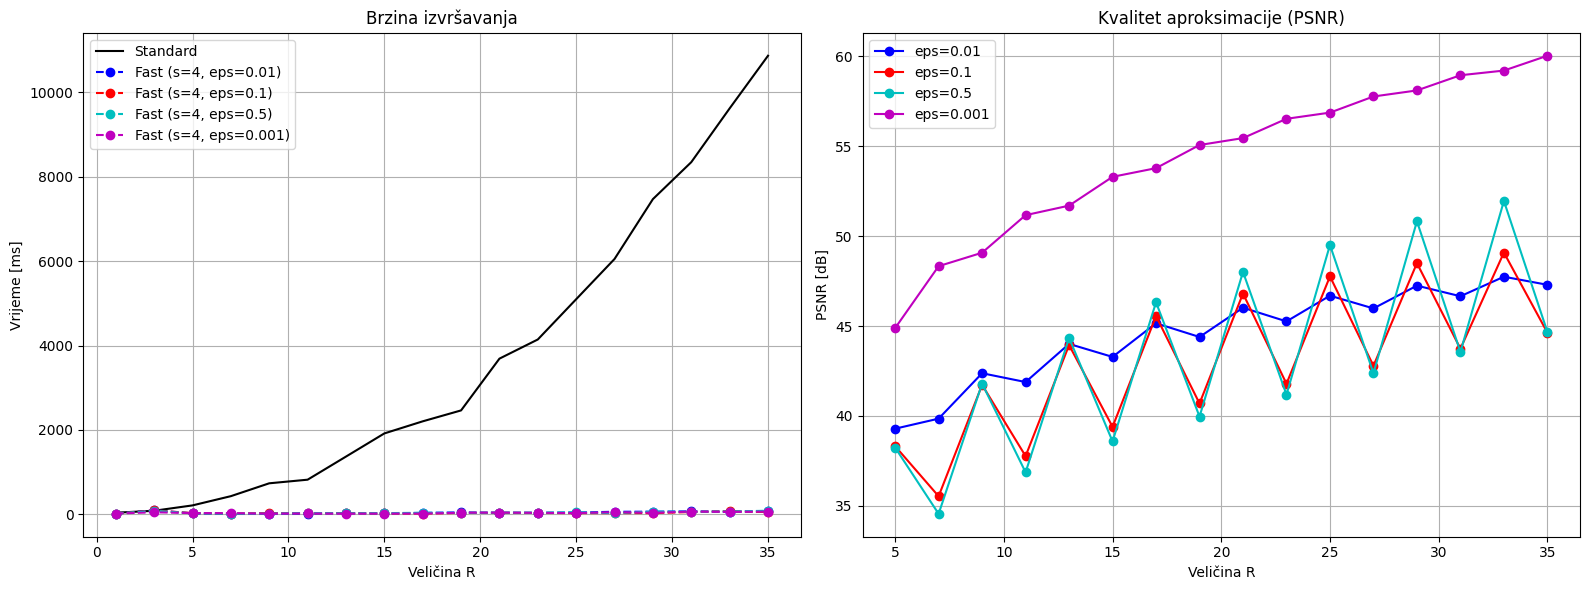

In [18]:
# f-ja za racunanje psnr-a (formula kao sa predavanja)
def calculate_psnr(img_ref, img_test):
    mse = np.mean((img_ref - img_test) ** 2)
    if mse == 0: return float('inf')
    return 10 * np.log10(1.0 / mse)

# test slike (na grafiku je prikazana lena.tif)
img_lena = util.img_as_float(io.imread(data_dir + "lena.tif"))
img_roof = util.img_as_float(io.imread(data_dir + "roof.jpg"))
img_einstein = util.img_as_float(io.imread(data_dir + "einstein.tif"))
img_lena_color = util.img_as_float(io.imread(data_dir + "lena.png"))

# dalje je samo klasican kod za plotovanje rezultata
s_fixed = 4
epsilon_values = [0.01, 0.1, 0.5, 0.001] 
Rs = range(1, 36, 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = ['b', 'r', 'c', 'm']

for i, e in enumerate(epsilon_values):
    times_std = []
    times_fast = []
    psnr_values = []
    
    for R in Rs:
        start = time.time()
        res_std = dos_self_guided_filter(img_lena, R, e)
        times_std.append((time.time() - start) * 1000)
        
        start = time.time()
        res_fast = dos_fast_self_guided_filter(img_lena, R, e, s=s_fixed)
        times_fast.append((time.time() - start) * 1000)
        
        p = calculate_psnr(res_std, res_fast)
        psnr_values.append(p)
    
    color = colors[i % len(colors)]
    if i == 0:
        ax1.plot(Rs, times_std, linestyle='-', color='k', label='Standard')
    
    ax1.plot(Rs, times_fast, linestyle='--', marker='o', color=color, label=f'Fast (s={s_fixed}, eps={e})')
    ax2.plot(Rs, psnr_values, linestyle='-', marker='o', color=color, label=f'eps={e}')


ax1.set_title('Brzina izvršavanja')
ax1.set_xlabel('Veličina R')
ax1.set_ylabel('Vrijeme [ms]')
ax1.legend()
ax1.grid(True)

ax2.set_title('Kvalitet aproksimacije (PSNR)')
ax2.set_xlabel('Veličina R')
ax2.set_ylabel('PSNR [dB]')
ax2.legend()
ax2.grid(True)

plt.tight_layout()

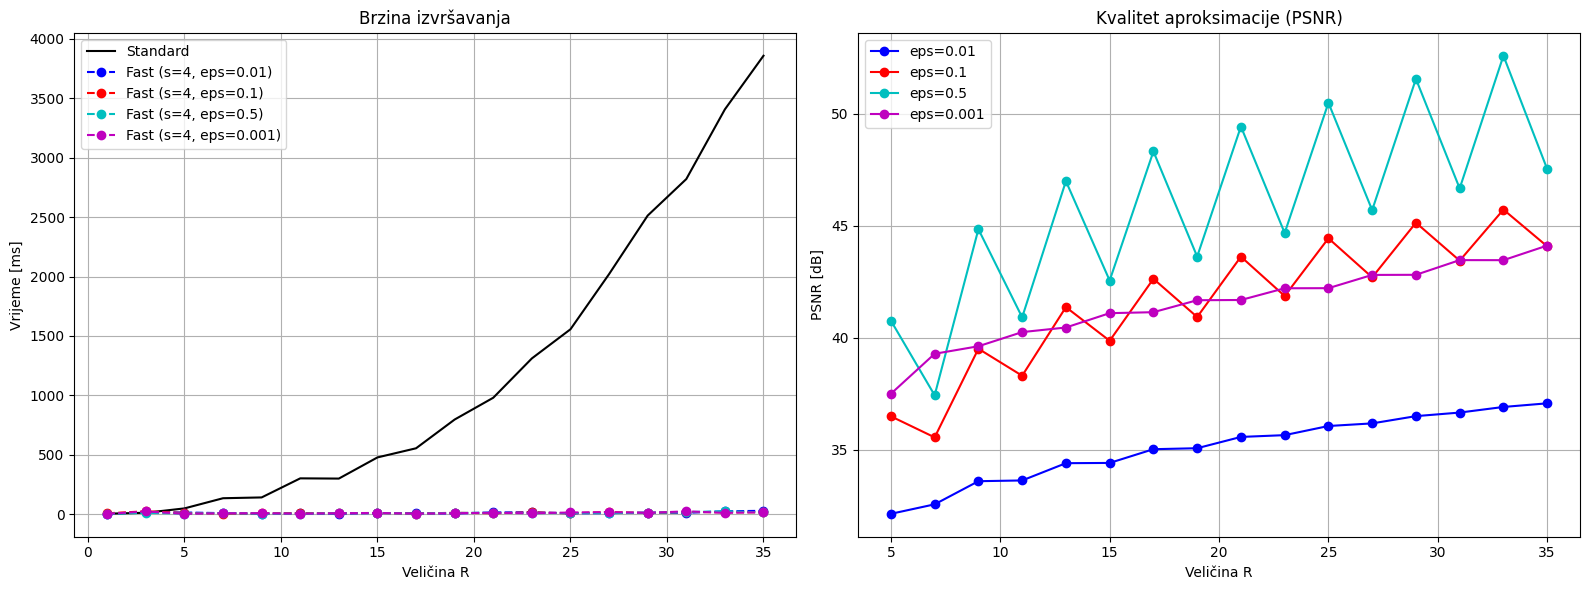

In [50]:
# f-ja za racunanje psnr-a (formula kao sa predavanja)
def calculate_psnr(img_ref, img_test):
    mse = np.mean((img_ref - img_test) ** 2)
    if mse == 0: return float('inf')
    return 10 * np.log10(1.0 / mse)

# test slike (na grafiku je prikazana lena.tif)
img_lena = util.img_as_float(io.imread(data_dir + "lena.tif"))
img_roof = util.img_as_float(io.imread(data_dir + "roof.jpg"))
img_einstein = util.img_as_float(io.imread(data_dir + "einstein.tif"))
img_lena_color = util.img_as_float(io.imread(data_dir + "lena.png"))

# dalje je samo klasican kod za plotovanje rezultata
s_fixed = 4
epsilon_values = [0.01, 0.1, 0.5, 0.001] 
Rs = range(1, 36, 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = ['b', 'r', 'c', 'm']

for i, e in enumerate(epsilon_values):
    times_std = []
    times_fast = []
    psnr_values = []
    
    for R in Rs:
        start = time.time()
        res_std = dos_self_guided_filter(img_einstein, R, e)
        times_std.append((time.time() - start) * 1000)
        
        start = time.time()
        res_fast = dos_fast_self_guided_filter(img_einstein, R, e, s=s_fixed)
        times_fast.append((time.time() - start) * 1000)
        
        p = calculate_psnr(res_std, res_fast)
        psnr_values.append(p)
    
    color = colors[i % len(colors)]
    if i == 0:
        ax1.plot(Rs, times_std, linestyle='-', color='k', label='Standard')
    
    ax1.plot(Rs, times_fast, linestyle='--', marker='o', color=color, label=f'Fast (s={s_fixed}, eps={e})')
    ax2.plot(Rs, psnr_values, linestyle='-', marker='o', color=color, label=f'eps={e}')


ax1.set_title('Brzina izvršavanja')
ax1.set_xlabel('Veličina R')
ax1.set_ylabel('Vrijeme [ms]')
ax1.legend()
ax1.grid(True)

ax2.set_title('Kvalitet aproksimacije (PSNR)')
ax2.set_xlabel('Veličina R')
ax2.set_ylabel('PSNR [dB]')
ax2.legend()
ax2.grid(True)

plt.tight_layout()

Grafik zavisnosti vremena izvršavanja od veličine prozora $R$ prikazuje veliku razliku između standardne i brze implementacije:
- Standardni filtar: Primjećuje se kvadratni (ili eksponencijalni) rast vremena izvršavanja. Za male vrijednosti $R$, vrijeme je zanemarljivo, ali kako
$R$ raste, vrijeme skače i na preko $10$ sekundi. Ovo je direktna posljedica korišćenja `ndi.convolve`. Složenost ove operacije je $O(N \cdot R^2)$, gdje je $N$ broj piksela. Povećanjem $R$, površina kernela raste kvadratno, a samim tim i broj operacija. Ovo jasno ilustruje zašto su standardni algoritmi neprimjenljivi za velike kernele u obradi slike u realnom vremenu.

- Fast filtar: Vrijeme izvršavanja je skoro ravna linija bliska nuli u poređenju sa standardnim filtrom. Ovo ubrzanje je posljedica decimacije ulazne slike za faktor $s = 4$. Broj piksela koji se obrađuju je smanjen za faktor $s^2 = 16$. Efektivni radijus filtra na smanjenoj slici je takođe smanjen $(R_{sub} \approx R / 4)$, što dodatno smanjuje broj operacija konvolucije. Korišćenje optimizovane interpolacije omogućilo je da overhead skaliranja bude minimalan.

Da je korišćen `uniform_filter`, crna linija bi bila ravna i znatno niža, jer je njegova složenost nezavisna od $R$. Međutim, čak i tada, Fast filtar bi bio brži zbog rada sa 16 puta manje podataka, čime se štedi memorijski protok.

Grafik PSNR-a prikazuje grešku koju unosimo korišćenjem Fast Self-Guided filtra u odnosu na standardni Self-Guided filtar. Generalni trend grafika je rastući. Što je veći prozor $R$ to je PSNR veći (greška manja). Veliki prozori $R$ vrše snažno usrednjavanje slike, uklanjajući fine detalje i šum, ostavljajući samo niskofrekventne komponente. Kada takvu mapu koeficijenata ($a$ i $b$) decimiramo i ponovo interpoliramo, gubitak informacija je minimalan. Nasuprot tome, mali prozori čuvaju fine detalje koji se nepovratno gube ili kvare pri decimaciji, što rezultuje manjim PSNR-om na početku grafika. Što se tiče grafika sa izrazitim cik-cak oblikom, to nije greška, nego posljedica diskretizacije prostora pri skaliranju. Poluprečnik filtra se na decimiranoj slici računa kao cjelobrojna vrijednost. Maksimumi se javljaju kada je $R$ djeljivo sa $s$. Tada se geometrija filtra na smanjenoj slici savršeno poklapa sa geometrijom originalnog filtra. Nasuprot ovome, minimumi se javljaju kada $R$ nije djeljivo sa $s$ i tada dolazi do zaokruživanja i efektivno, filtar tada zahvata malo više ili malo manje nego što bi trebalo što na kraju stvara grešku aproksimacije. 

Filtri su primjenjeni na dvije različite slike.

#### BONUS

Pokušala sam da uradim ali jednostavno nije išlo. Dobije se kao i neka OK slika, a i kernel nije loš (vidi se tačno ona dijagonalna spirala koja predstavlja kernel za sliku etf_blur.png), ali opet to nije skroz dobar rezultat. Mislim da je bio problem u dekonvoluciji, ali nisam imala baš vremena da se posvetim tome i uradim bonus kako treba do kraja. U svakom slučaju, ispod se nalazi najbolji rezultat koji sam mogla da dobijem...
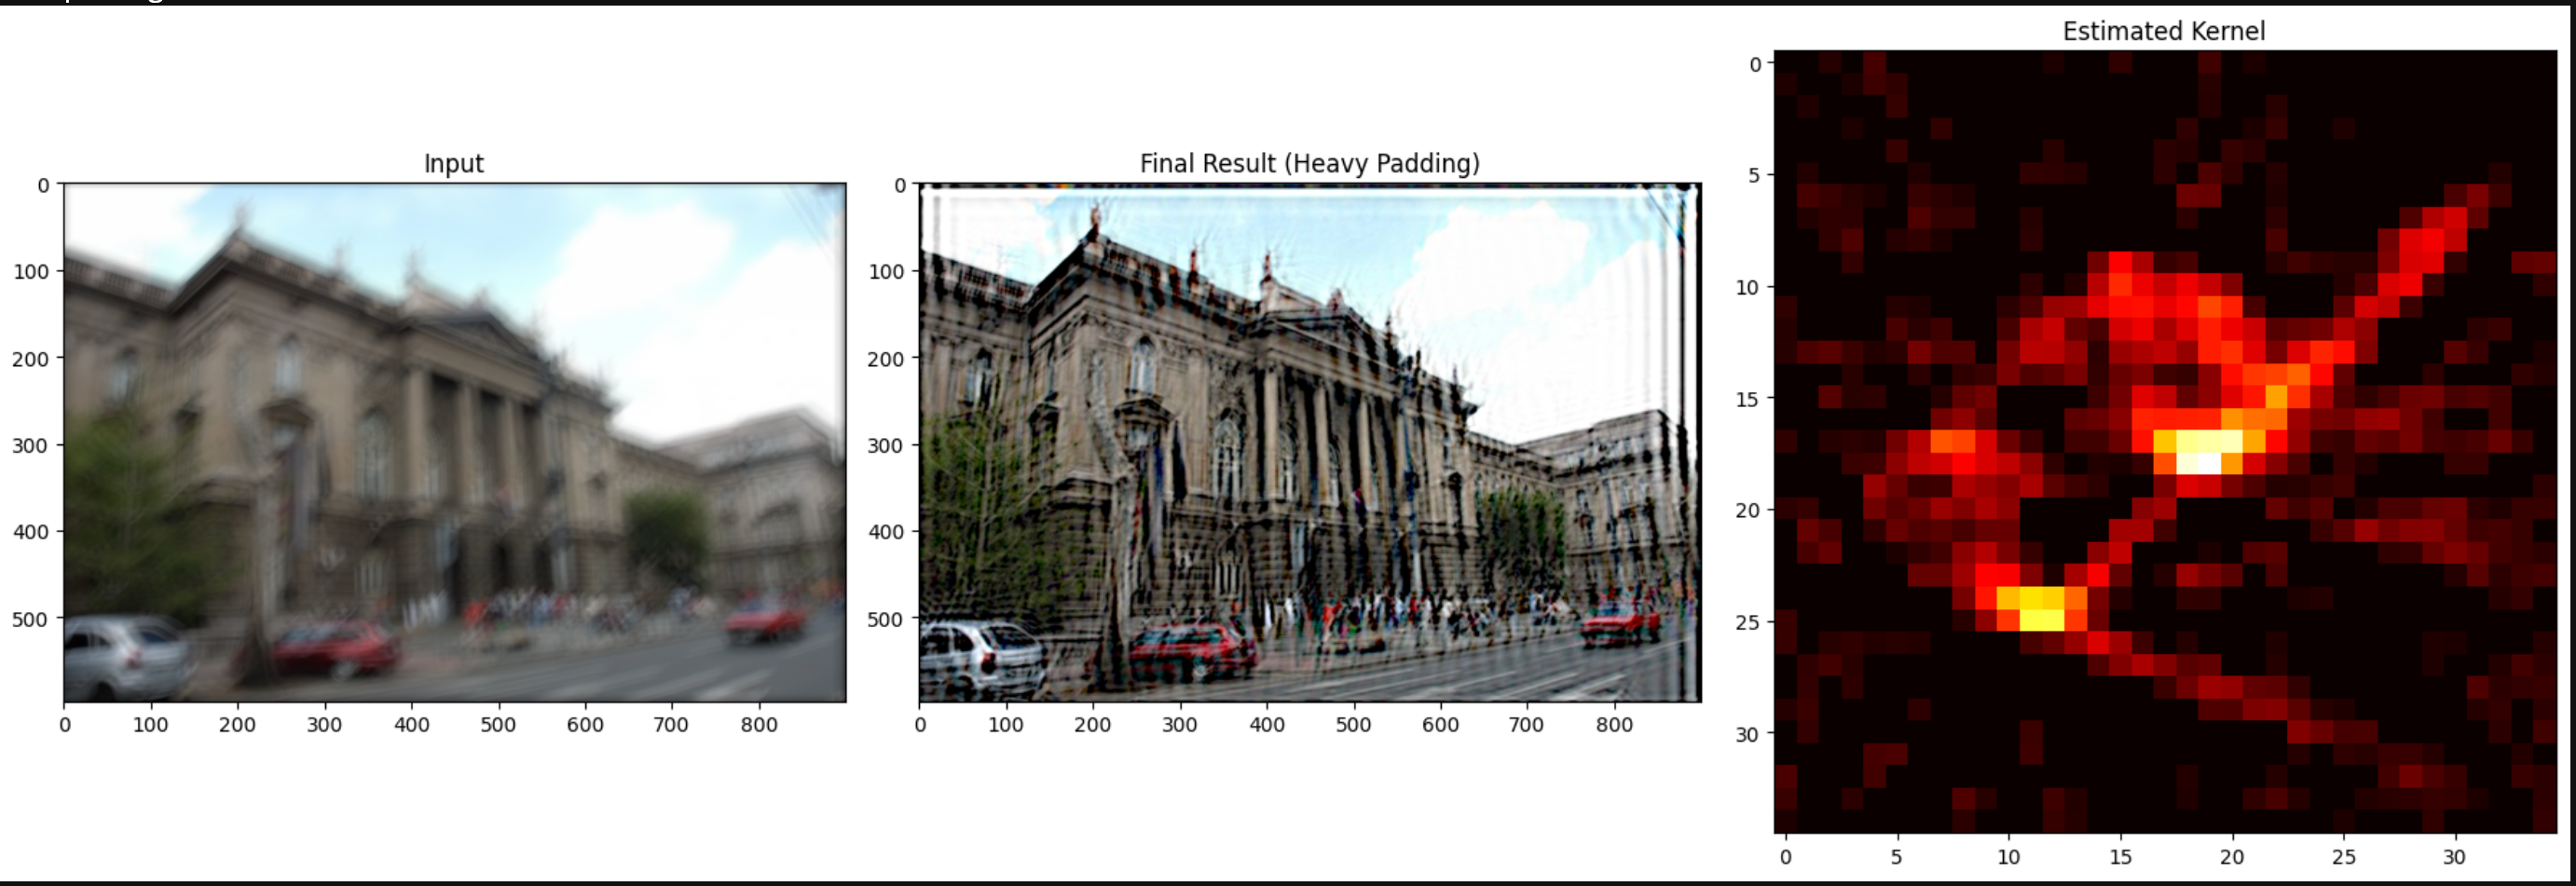